# Markov Chain Monte Carlo (MCMC) and Variational Inference

This notebook provides an overview of MCMC and Variational Inference. It is organized into the following sections:

**1: MCMC Theory and Samplers**  
Theoretical foundations, key definitions, and implementations of standard samplers such as Metropolis–Hastings, Gibbs, Hamiltonian Monte Carlo (HMC), Slice Sampling, and Adaptive Metropolis.

**2: Variational Inference**  
Theory behind Variational Inference including the Evidence Lower Bound (ELBO), the reparameterization trick, as well as examples of mean‐field VI and stochastic VI (SVI).

**3: Applications**  
1. Bayesian Logistic Regression
2. Bayesian Linear Regression
3. Hierarchical and Multilevel Models
4. Mixture Models and Clustering
5. Hidden Markov Model Inference
6. AR(1) Time Series Parameter Estimation
7. Option Pricing via Monte Carlo Simulation
8. Multidimensional Numerical Integration
9. Computing Partition Functions
10. Volume Estimation
11. Epidemiological Modeling
12. Cryptographic Decoding
13. Simulated Annealing for Global Optimization
14. Molecular Dynamics and Conformational Sampling
15. Geostatistical Modeling
16. Ecological Modeling
17. Phylogenetics
18. Population Genetics

**4: Implementation Considerations and Optimizations**  
Guidelines on tuning, numerical stability, initialization/burn-in, diagnostics, and parallelization.

**5: Advanced Variants and Extensions**  
Overviews of advanced MCMC (e.g. No-U-Turn Sampler, Reversible Jump MCMC, Parallel Tempering, Sequential Monte Carlo) and advanced VI techniques (e.g. IWAE, Normalizing Flows, VAEs, SVGD).

**6: Conclusion and Further Reading**  
A brief conclusion and additional references.

## 1: MCMC Theory and Samplers

### Comparison of MCMC vs. Variational Inference (VI)

| Method | Pros                                               | Cons                                            | Typical Use Cases                                |
|--------|----------------------------------------------------|-------------------------------------------------|--------------------------------------------------|
| MCMC   | Asymptotically exact; handles multi-modal targets  | Computationally intensive; slow convergence     | Small to moderate datasets; high-accuracy tasks   |
| VI     | Fast and scalable; deterministic optimization      | Approximation bias; may underestimate uncertainty | Large datasets; real-time inference              |

### Comparison of MCMC Samplers

| Sampler                          | Pros                                                        | Cons                                                 |
|----------------------------------|-------------------------------------------------------------|------------------------------------------------------|
| Metropolis–Hastings              | Simple and general-purpose                                  | May be inefficient in high dimensions; needs tuning  |
| Gibbs                            | Efficient when full conditionals are available              | Only applicable when conditionals are tractable      |
| Hamiltonian Monte Carlo (HMC)      | Uses gradient information for efficient exploration         | Requires gradient calculation; sensitive to step size|
| Slice Sampling                   | Automatically adjusts step size; no manual tuning required    | Can be slow in high dimensions                       |
| Adaptive Metropolis              | Adapts proposal based on performance; improves mixing       | Requires burn-in period for adaptation               |

### 1.1 Key Definitions and Concepts in MCMC

**Markov Chain**: A sequence of random variables $(X^{(1)}, X^{(2)}, \dots)$ that satisfies the Markov property:

$$ P(X^{(n+1)} = x_{n+1} \mid X^{(1)} = x_1, \dots, X^{(n)} = x_n) = P(X^{(n+1)} = x_{n+1} \mid X^{(n)} = x_n). $$

**Stationary Distribution**: A probability distribution $\pi(x)$ is stationary for a Markov chain with transition kernel $K(x,y)$ if

$$ \pi(y) = \int \pi(x) \; K(x,y) \; dx $$

for all $y$. This means if $X^{(n)} \sim \pi(x)$, then $X^{(n+1)}$ is also distributed as $\pi(x)$.

**Ergodicity**: A Markov chain is ergodic if, regardless of the starting state, $X^{(n)}$ converges in distribution to the stationary distribution $\pi(x)$ as $n \to \infty$.

**Detailed Balance**: A condition ensuring that $\pi(x)$ is the stationary distribution. A chain with transition kernel $K(x,y)$ satisfies detailed balance with respect to $\pi(x)$ if

$$ \pi(x) \; K(x,y) = \pi(y) \; K(y,x) $$

for all $x$ and $y$. This means the probability flow from $x$ to $y$ equals the flow from $y$ to $x$, ensuring the chain is reversible.

**Reversibility**: A Markov chain is reversible if it satisfies detailed balance. Reversibility implies that the behavior of the chain is the same when observed backward in time, which simplifies theoretical analysis.

**Effective Sample Size (ESS)**: Because MCMC samples are correlated, the effective sample size estimates the number of independent samples. A common formula is

$$ N_{\text{eff}} = \frac{N}{1 + 2 \sum_{k=1}^{\infty} \rho_k}, $$

where $\rho_k$ is the autocorrelation at lag $k$.

**Autocorrelation and Mixing**: Autocorrelation measures the similarity between samples at different lags; high autocorrelation indicates poor mixing. Good mixing means the chain quickly forgets its starting point and explores the state space efficiently.

**Convergence Diagnostics**: Tools such as trace plots, autocorrelation plots, and the Gelman-Rubin statistic ($\hat{R}$) are used to assess whether a chain has converged to its stationary distribution.

**Markov Chain Central Limit Theorem (CLT)**: If $X^{(1)}, \dots, X^{(N)}$ are samples from a stationary Markov chain and $\hat{I}_N(f)$ estimates

$$ I(f) = \int f(x)\pi(x)\,dx, $$

then

$$ \sqrt{N}(\hat{I}_N(f)-I(f)) \xrightarrow{d} \mathcal{N}(0, \sigma^2_{\text{eff}}), $$

where

$$ \sigma^2_{\text{eff}} = \mathrm{Var}_{\pi}(f) + 2 \sum_{k=1}^{\infty} \mathrm{Cov}(f(X^{(0)}), f(X^{(k)})). $$

These definitions lay the foundation for understanding and designing effective MCMC algorithms.

## 2: Variational Inference

### 2.1 Theory and the ELBO

Variational Inference approximates the posterior $p(z \mid x)$ by finding a distribution $q(z) \in \mathcal{Q}$ that minimizes the KL divergence:

$$ q^*(z) = \arg\min_{q(z) \in \mathcal{Q}} \mathrm{KL}(q(z) \parallel p(z \mid x)). $$

This leads to the Evidence Lower Bound (ELBO):

$$ \mathrm{ELBO}(q) = \mathbb{E}_{q(z)}[\log p(z,x)] - \mathbb{E}_{q(z)}[\log q(z)]. $$

Since

$$ \log p(x) = \mathrm{ELBO}(q) + \mathrm{KL}(q(z) \parallel p(z \mid x)), $$

maximizing the ELBO is equivalent to minimizing the KL divergence between $q(z)$ and $p(z \mid x)$.

### 2.2 Mean-Field Variational Inference

In mean-field VI, we assume that the variational distribution factorizes as follows:

$$ q(z) = \prod_i q_i(z_i). $$

Below is an example where we approximate a univariate target density with a Gaussian variational distribution $q(z) = \mathcal{N}(z \mid \mu, \sigma^2)$ by optimizing the ELBO.

Optimal VI parameters: mu = 0.000, sigma = 1.000


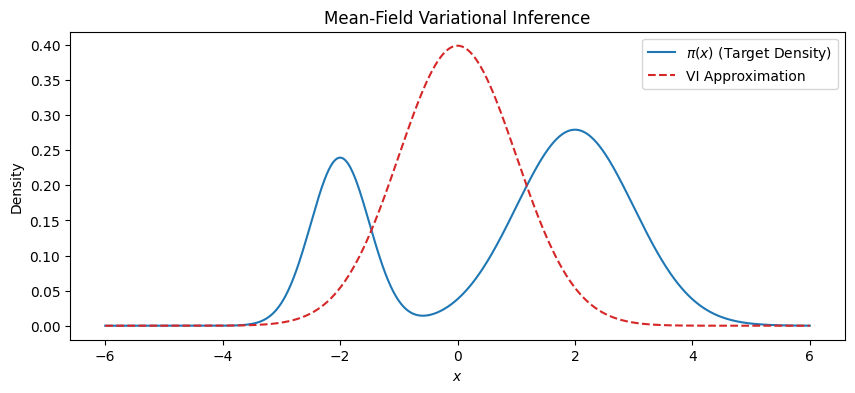

In [1]:
import numpy as np
from scipy.stats import norm

def target_density(x):
    """
    Bimodal target: mixture of two Gaussians.
    """
    return 0.3 * norm.pdf(x, loc=-2, scale=0.5) + 0.7 * norm.pdf(x, loc=2, scale=1.0)

def log_target(x):
    return np.log(target_density(x) + 1e-10)

def elbo(params):
    mu, log_sigma = params
    sigma = np.exp(log_sigma)
    z_samples = np.random.normal(mu, sigma, size=1000)
    from scipy.stats import norm
    log_qz = norm.logpdf(z_samples, loc=mu, scale=sigma)
    log_pzx = log_target(z_samples)
    return - (np.mean(log_pzx) - np.mean(log_qz))

import scipy.optimize as opt
init_params = [0.0, 0.0]
result = opt.minimize(elbo, init_params, method='Nelder-Mead', options={'maxiter': 5000})
mu_opt, log_sigma_opt = result.x
sigma_opt = np.exp(log_sigma_opt)
print(f"Optimal VI parameters: mu = {mu_opt:.3f}, sigma = {sigma_opt:.3f}")

x_vals = np.linspace(-6, 6, 1000)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(x_vals, target_density(x_vals), label='$\pi(x)$ (Target Density)', color='C0')
from scipy.stats import norm
plt.plot(x_vals, norm.pdf(x_vals, loc=mu_opt, scale=sigma_opt), label='VI Approximation', linestyle='--', color='C3')
plt.title('Mean-Field Variational Inference')
plt.xlabel('$x$')
plt.ylabel('Density')
plt.legend()
plt.show()

### 2.3 Stochastic Variational Inference (SVI)

SVI uses mini-batch stochastic gradient ascent to optimize the ELBO. Below, we use finite differences to approximate the gradient for a simple univariate model.

Iteration 0: ELBO = -85.444
Iteration 200: ELBO = -77.444
Iteration 400: ELBO = -69.444
Iteration 600: ELBO = -61.444
Iteration 800: ELBO = -64.677
SVI optimized parameters: mu = -156.863, sigma = 0.000


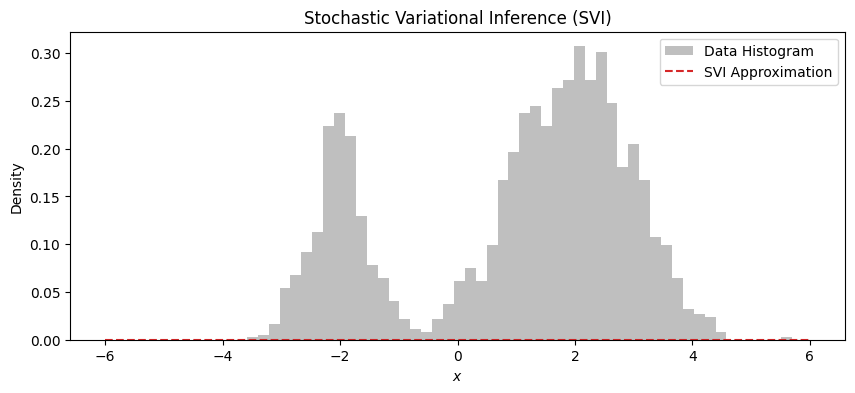

In [2]:
def svi_update(mu, log_sigma, data, batch_size=50, lr=0.01, n_iters=1000):
    import numpy as np
    n = len(data)
    for iter in range(n_iters):
        idx = np.random.choice(n, batch_size, replace=False)
        batch = data[idx]
        eps = 1e-5
        grad_mu = (elbo([mu + eps, log_sigma]) - elbo([mu - eps, log_sigma])) / (2 * eps)
        grad_log_sigma = (elbo([mu, log_sigma + eps]) - elbo([mu, log_sigma - eps])) / (2 * eps)
        scale = n / batch_size
        mu = mu - lr * scale * grad_mu
        log_sigma = log_sigma - lr * scale * grad_log_sigma
        if iter % 200 == 0:
            current_elbo = -elbo([mu, log_sigma])
            print(f"Iteration {iter}: ELBO = {current_elbo:.3f}")
    return mu, log_sigma

data = np.concatenate([np.random.normal(-2, 0.5, 500), np.random.normal(2, 1.0, 1500)])
mu_init, log_sigma_init = 0.0, 0.0
mu_svi, log_sigma_svi = svi_update(mu_init, log_sigma_init, data, batch_size=50, lr=0.001, n_iters=1000)
sigma_svi = np.exp(log_sigma_svi)
print(f"SVI optimized parameters: mu = {mu_svi:.3f}, sigma = {sigma_svi:.3f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.hist(data, bins=50, density=True, alpha=0.5, label='Data Histogram', color='gray')
plt.plot(x_vals, norm.pdf(x_vals, loc=mu_svi, scale=sigma_svi), label='SVI Approximation', linestyle='--', color='C3')
plt.title('Stochastic Variational Inference (SVI)')
plt.xlabel('$x$')
plt.ylabel('Density')
plt.legend()
plt.show()

### 2.4 Black-Box VI and the Reparameterization Trick

For a Gaussian variational distribution, we can reparameterize as follows:

$$ z = \mu + \sigma \epsilon, \quad \epsilon \sim \mathcal{N}(0, 1), $$

which enables efficient gradient computation with respect to $\mu$ and $\sigma$ using automatic differentiation.

## 3: Applications

### 3.1 Bayesian Logistic Regression

We generate a synthetic binary classification dataset and perform posterior inference for the regression coefficients $\beta$. The logistic model is given by

$$ P(y_i = 1 \mid x_i, \beta) = \sigma(x_i^T \beta), \quad \sigma(z) = \frac{1}{1+e^{-z}}, $$

with a Gaussian prior $\beta \sim \mathcal{N}(0, \tau^2 I)$ and a corresponding log-posterior.

Logistic Regression MH Acceptance Rate: 0.500
Posterior mean estimate of beta: [-1.01247874  1.58225165 -2.91309873]


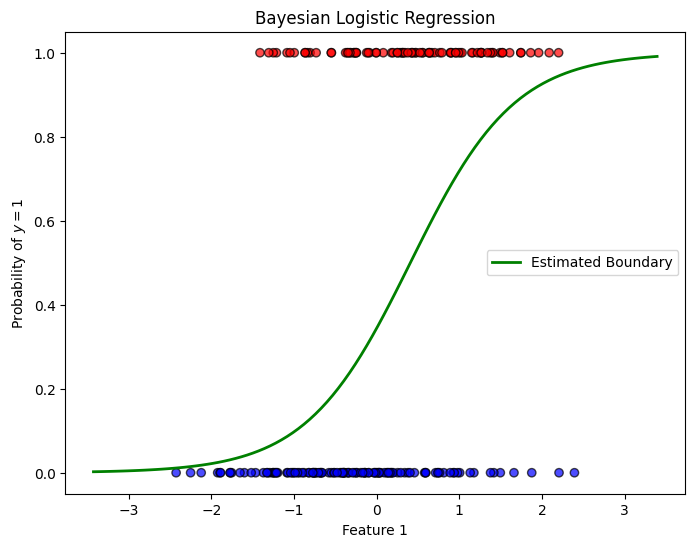

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def log_posterior_logistic(beta, X, y, tau2=10):
    logits = X @ beta
    log_lik = np.sum(y * np.log(sigmoid(logits) + 1e-10) + (1 - y) * np.log(1 - sigmoid(logits) + 1e-10))
    log_prior = -0.5 * np.sum(beta ** 2) / tau2
    return log_lik + log_prior

def metropolis_logistic(X, y, n_samples=5000, init_beta=None, proposal_cov=None):
    import numpy as np
    d = X.shape[1]
    if init_beta is None:
        init_beta = np.zeros(d)
    if proposal_cov is None:
        proposal_cov = 0.1 * np.eye(d)
    samples = np.zeros((n_samples, d))
    beta_current = init_beta.copy()
    log_post_current = log_posterior_logistic(beta_current, X, y)
    accepted = 0
    for i in range(n_samples):
        beta_proposal = np.random.multivariate_normal(beta_current, proposal_cov)
        log_post_proposal = log_posterior_logistic(beta_proposal, X, y)
        if np.random.rand() < np.exp(log_post_proposal - log_post_current):
            beta_current = beta_proposal
            log_post_current = log_post_proposal
            accepted += 1
        samples[i, :] = beta_current
    acceptance_rate = accepted / n_samples
    return samples, acceptance_rate

np.random.seed(123)
n = 200
d = 3
X = np.hstack([np.ones((n, 1)), np.random.randn(n, d - 1)])
true_beta = np.array([-1.0, 2.0, -3.0])
y = np.random.binomial(1, sigmoid(X @ true_beta))

beta_samples, acc_rate = metropolis_logistic(X, y, n_samples=10000, proposal_cov=0.05 * np.eye(d))
print(f"Logistic Regression MH Acceptance Rate: {acc_rate:.3f}")
beta_mean = np.mean(beta_samples, axis=0)
print(f"Posterior mean estimate of beta: {beta_mean}")

import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(X[:,1], y, c=y, cmap='bwr', alpha=0.7, edgecolor='k')
x_line = np.linspace(np.min(X[:,1]) - 1, np.max(X[:,1]) + 1, 100)
fixed_val = np.median(X[:,2])
logit_line = beta_mean[0] + beta_mean[1] * x_line + beta_mean[2] * fixed_val
plt.plot(x_line, sigmoid(logit_line), color='green', linewidth=2, label='Estimated Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Probability of $y=1$')
plt.title('Bayesian Logistic Regression')
plt.legend()
plt.show()

### 3.2 Bayesian Linear Regression

Consider the model

$$ y_i = x_i^T \beta + \epsilon_i, \quad \epsilon_i \sim \mathcal{N}(0, \sigma^2), $$

with a Gaussian prior $\beta \sim \mathcal{N}(0, \tau^2 I)$. The log-posterior is given by

$$ \log p(\beta \mid X,y) \propto -\frac{1}{2 \sigma^2}\sum_{i=1}^n (y_i - x_i^T \beta)^2 - \frac{1}{2 \tau^2}\beta^T \beta. $$

Bayesian Linear Regression MH Acceptance Rate: 0.192
Posterior mean estimate of beta: [1.0087708  2.43322884]


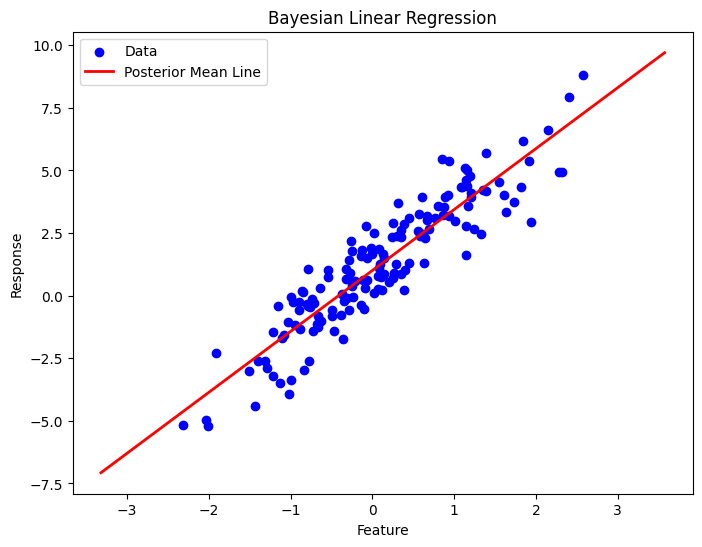

In [4]:
def log_posterior_linear(beta, X, y, sigma2=1.0, tau2=10):
    resid = y - X @ beta
    log_lik = -0.5 * np.sum(resid ** 2) / sigma2
    log_prior = -0.5 * np.sum(beta ** 2) / tau2
    return log_lik + log_prior

def metropolis_linear(X, y, n_samples=5000, init_beta=None, proposal_cov=None, sigma2=1.0, tau2=10):
    import numpy as np
    d = X.shape[1]
    if init_beta is None:
        init_beta = np.zeros(d)
    if proposal_cov is None:
        proposal_cov = 0.1 * np.eye(d)
    samples = np.zeros((n_samples, d))
    beta_current = init_beta.copy()
    log_post_current = log_posterior_linear(beta_current, X, y, sigma2, tau2)
    accepted = 0
    for i in range(n_samples):
        beta_proposal = np.random.multivariate_normal(beta_current, proposal_cov)
        log_post_proposal = log_posterior_linear(beta_proposal, X, y, sigma2, tau2)
        if np.random.rand() < np.exp(log_post_proposal - log_post_current):
            beta_current = beta_proposal
            log_post_current = log_post_proposal
            accepted += 1
        samples[i, :] = beta_current
    acceptance_rate = accepted / n_samples
    return samples, acceptance_rate

np.random.seed(456)
n_lin = 150
d_lin = 2
import numpy as np
X_lin = np.hstack([np.ones((n_lin, 1)), np.random.randn(n_lin, d_lin - 1)])
true_beta_lin = np.array([1.0, 2.5])
y_lin = X_lin @ true_beta_lin + np.random.normal(0, 1.0, n_lin)

beta_lin_samples, lin_acc_rate = metropolis_linear(X_lin, y_lin, n_samples=5000, proposal_cov=0.05 * np.eye(d_lin))
print(f"Bayesian Linear Regression MH Acceptance Rate: {lin_acc_rate:.3f}")
beta_lin_mean = np.mean(beta_lin_samples, axis=0)
print(f"Posterior mean estimate of beta: {beta_lin_mean}")

import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(X_lin[:,1], y_lin, c='blue', label='Data')
x_plot = np.linspace(np.min(X_lin[:,1]) - 1, np.max(X_lin[:,1]) + 1, 100)
y_plot = beta_lin_mean[0] + beta_lin_mean[1] * x_plot
plt.plot(x_plot, y_plot, color='red', linewidth=2, label='Posterior Mean Line')
plt.xlabel('Feature')
plt.ylabel('Response')
plt.title('Bayesian Linear Regression')
plt.legend()
plt.show()

### 3.3 Hierarchical and Multilevel Models

Consider a hierarchical normal model:

$$ y_{ij} \sim \mathcal{N}(\mu_j, \sigma^2), $$

and

$$ \mu_j \sim \mathcal{N}(\mu, \tau^2). $$

Below, a Gibbs sampler is used to sample the overall mean $\mu$ and the group means $\mu_j$.

Posterior mean for overall $\mu$: 3.361


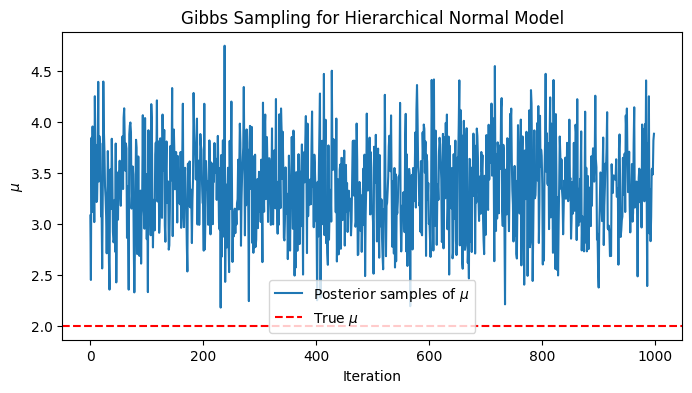

In [5]:
def gibbs_hierarchical(y, n_iter=1000):
    import numpy as np
    G, n = y.shape
    sigma2 = 1.0
    tau2 = 1.0
    mu0 = 0.0
    sigma0 = 10.0
    mu_j = np.mean(y, axis=1)
    mu = np.mean(mu_j)
    samples_mu = []
    samples_mu_j = []
    for it in range(n_iter):
        for j in range(G):
            var_j = 1 / (n / sigma2 + 1 / tau2)
            mean_j = var_j * (np.sum(y[j, :]) / sigma2 + mu / tau2)
            mu_j[j] = np.random.normal(mean_j, np.sqrt(var_j))
        var_mu = 1 / (G / tau2 + 1 / sigma0**2)
        mean_mu = var_mu * (np.sum(mu_j) / tau2 + mu0 / sigma0**2)
        mu = np.random.normal(mean_mu, np.sqrt(var_mu))
        samples_mu.append(mu)
        samples_mu_j.append(mu_j.copy())
    return np.array(samples_mu), np.array(samples_mu_j)

import numpy as np
np.random.seed(0)
G = 5
n_obs = 10
true_mu = 2.0
true_tau = 1.0
true_sigma = 1.0
true_mu_j = np.random.normal(true_mu, true_tau, size=G)
y = np.zeros((G, n_obs))
for j in range(G):
    y[j, :] = np.random.normal(true_mu_j[j], true_sigma, size=n_obs)

samples_mu, samples_mu_j = gibbs_hierarchical(y, n_iter=1000)
print(f"Posterior mean for overall $\mu$: {np.mean(samples_mu):.3f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(samples_mu, label='Posterior samples of $\mu$')
plt.axhline(true_mu, color='red', linestyle='--', label='True $\mu$')
plt.xlabel('Iteration')
plt.ylabel('$\mu$')
plt.title('Gibbs Sampling for Hierarchical Normal Model')
plt.legend()
plt.show()

### 3.4 Mixture Models and Clustering

Consider a simple Gaussian mixture model with two components:

$$ x_i \sim \pi \; \mathcal{N}(\mu_1, \sigma^2) + (1-\pi) \; \mathcal{N}(\mu_2, \sigma^2). $$

A Gibbs sampler alternates between updating the cluster assignments and the component means.

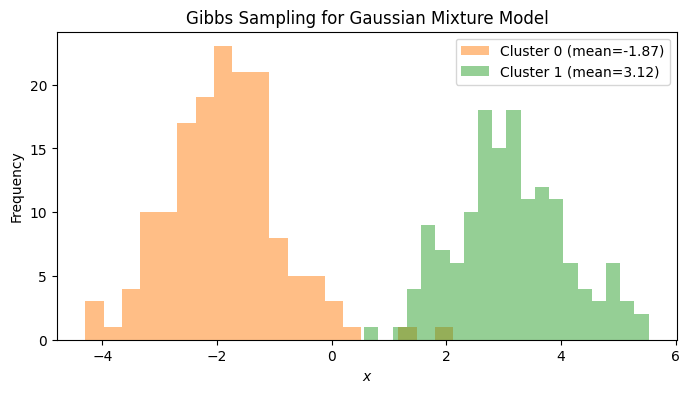

In [6]:
def gibbs_gmm(x, n_iter=500, sigma2=1.0):
    import numpy as np
    n = len(x)
    z = np.random.randint(0, 2, size=n)  # initial cluster assignments
    mu1 = np.mean(x) - 1
    mu2 = np.mean(x) + 1
    samples = []
    for it in range(n_iter):
        for i in range(n):
            p1 = np.exp(-0.5 * ((x[i] - mu1) ** 2) / sigma2)
            p2 = np.exp(-0.5 * ((x[i] - mu2) ** 2) / sigma2)
            prob = p1 / (p1 + p2 + 1e-10)
            z[i] = 1 if np.random.rand() > prob else 0
        if np.sum(z == 0) > 0:
            mu1 = np.mean(x[z == 0])
        if np.sum(z == 1) > 0:
            mu2 = np.mean(x[z == 1])
        samples.append((mu1, mu2, z.copy()))
    return samples

np.random.seed(1)
n_samples_gmm = 300
x_data = np.concatenate([np.random.normal(-2, 1.0, n_samples_gmm // 2),
                          np.random.normal(3, 1.0, n_samples_gmm // 2)])

gmm_samples = gibbs_gmm(x_data, n_iter=500, sigma2=1.0)
final_mu1, final_mu2, final_z = gmm_samples[-1]
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.hist(x_data[final_z == 0], bins=20, alpha=0.5, label=f'Cluster 0 (mean={final_mu1:.2f})', color='C1')
plt.hist(x_data[final_z == 1], bins=20, alpha=0.5, label=f'Cluster 1 (mean={final_mu2:.2f})', color='C2')
plt.xlabel('$x$')
plt.ylabel('Frequency')
plt.title('Gibbs Sampling for Gaussian Mixture Model')
plt.legend()
plt.show()

### 3.5 Hidden Markov Model Inference

Using forward filtering–backward sampling, we can infer the latent state sequence of a two-state HMM with fixed parameters.

Sampled latent state sequence: [1 1 1 1 1 1 1 1 1 1 0 1 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 1 1 1 0 1 0 0 1 0 1
 0 0 0 1 0 0 1 1 1 0 0 0 0]


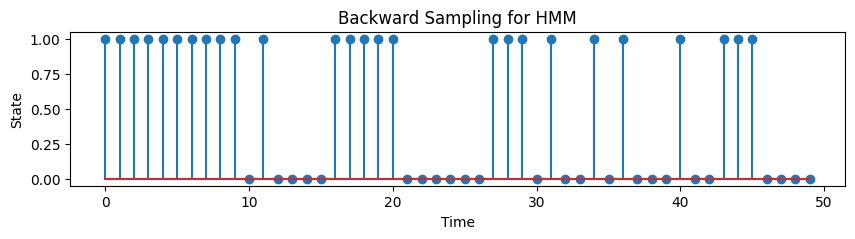

In [7]:
def forward_backward(observations, A, B, pi):
    import numpy as np
    T = len(observations)
    N = len(pi)
    alpha = np.zeros((T, N))
    alpha[0] = pi * B[:, observations[0]]
    for t in range(1, T):
        for j in range(N):
            alpha[t, j] = B[j, observations[t]] * np.sum(alpha[t-1] * A[:, j])
        alpha[t] /= np.sum(alpha[t])
    states = np.zeros(T, dtype=int)
    states[T-1] = np.random.choice(N, p=alpha[T-1])
    for t in range(T-2, -1, -1):
        prob = alpha[t] * A[:, states[t+1]]
        prob /= np.sum(prob)
        states[t] = np.random.choice(N, p=prob)
    return states

import numpy as np
observations = np.random.choice([0, 1], size=50, p=[0.5, 0.5])
A = np.array([[0.7, 0.3], [0.4, 0.6]])
B = np.array([[0.9, 0.1], [0.2, 0.8]])
pi = np.array([0.6, 0.4])
latent_states = forward_backward(observations, A, B, pi)
print("Sampled latent state sequence:", latent_states)

import matplotlib.pyplot as plt
plt.figure(figsize=(10,2))
plt.stem(latent_states)
plt.xlabel('Time')
plt.ylabel('State')
plt.title('Backward Sampling for HMM')
plt.show()

### 3.6 AR(1) Time Series Parameter Estimation

For an AR(1) process

$$ x_t = \phi x_{t-1} + \epsilon_t, \quad \epsilon_t \sim \mathcal{N}(0, \sigma^2), $$

we estimate the parameter $\phi$ using a Metropolis sampler.

Posterior mean estimate of $\phi$: 0.789


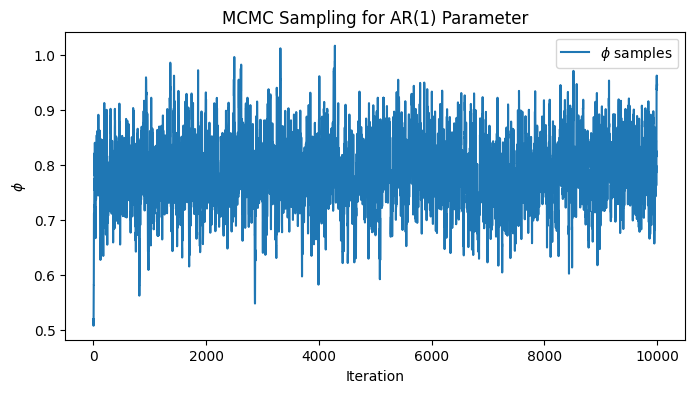

In [8]:
def generate_ar1(phi, sigma, n):
    import numpy as np
    x = np.zeros(n)
    for t in range(1, n):
        x[t] = phi * x[t-1] + np.random.normal(0, sigma)
    return x

def metropolis_ar1(x, n_samples=10000, phi_init=0.5, proposal_std=0.05):
    import numpy as np
    samples = []
    phi_current = phi_init
    n = len(x)
    log_like_current = 0
    for t in range(1, n):
        log_like_current += -0.5 * ((x[t] - phi_current * x[t-1]) ** 2)
    for i in range(n_samples):
        phi_proposal = np.random.normal(phi_current, proposal_std)
        log_like_proposal = 0
        for t in range(1, n):
            log_like_proposal += -0.5 * ((x[t] - phi_proposal * x[t-1]) ** 2)
        if np.random.rand() < np.exp(log_like_proposal - log_like_current):
            phi_current = phi_proposal
            log_like_current = log_like_proposal
        samples.append(phi_current)
    return np.array(samples)

import numpy as np
np.random.seed(0)
x_ar1 = generate_ar1(phi=0.7, sigma=1.0, n=100)
phi_samples = metropolis_ar1(x_ar1, n_samples=10000, phi_init=0.5, proposal_std=0.05)
print(f"Posterior mean estimate of $\phi$: {np.mean(phi_samples):.3f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(phi_samples, label='$\phi$ samples')
plt.xlabel('Iteration')
plt.ylabel('$\phi$')
plt.title('MCMC Sampling for AR(1) Parameter')
plt.legend()
plt.show()

### 3.7 Option Pricing via Monte Carlo Simulation

We simulate stock price paths using geometric Brownian motion to price a European call option. The stock evolves as

$$ S_t = S_0 \exp\Bigl((r - \frac{1}{2}\sigma^2)t + \sigma W_t\Bigr), $$

and the option payoff is

$$ \max(S_T - K, 0). $$

The option price is the discounted expected payoff.

Estimated European call option price: 8.08


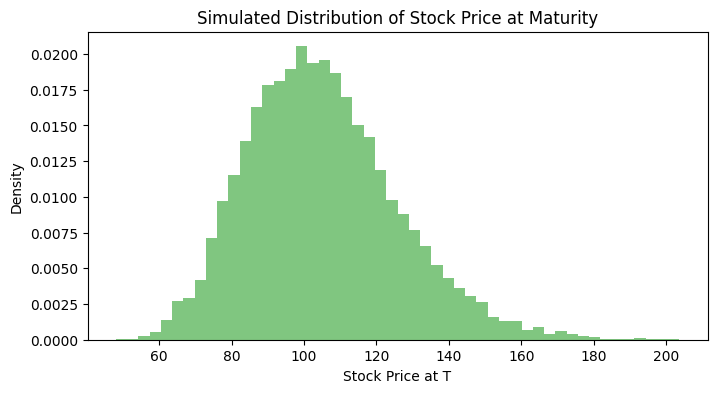

In [9]:
def simulate_stock_price(S0, r, sigma, T, n_steps):
    import numpy as np
    dt = T / n_steps
    prices = [S0]
    for i in range(n_steps):
        dW = np.random.normal(0, np.sqrt(dt))
        S_new = prices[-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * dW)
        prices.append(S_new)
    return prices

def price_european_call(S0, K, r, sigma, T, n_steps=100, n_sim=10000):
    import numpy as np
    payoffs = []
    for _ in range(n_sim):
        prices = simulate_stock_price(S0, r, sigma, T, n_steps)
        payoff = max(prices[-1] - K, 0)
        payoffs.append(payoff)
    option_price = np.exp(-r * T) * np.mean(payoffs)
    return option_price

S0 = 100
K = 105
r = 0.05
sigma = 0.2
T = 1.0
call_price = price_european_call(S0, K, r, sigma, T, n_steps=100, n_sim=10000)
print(f"Estimated European call option price: {call_price:.2f}")

import matplotlib.pyplot as plt
prices_T = [simulate_stock_price(S0, r, sigma, T, 100)[-1] for _ in range(10000)]
plt.figure(figsize=(8,4))
plt.hist(prices_T, bins=50, density=True, alpha=0.6, color='C2')
plt.xlabel('Stock Price at T')
plt.ylabel('Density')
plt.title('Simulated Distribution of Stock Price at Maturity')
plt.show()

### 3.8 Multidimensional Numerical Integration

Consider the integral

$$ I = \int_{[0,1]^d} e^{-\sum_{i=1}^d x_i} \, dx, $$

with the exact value in $d$ dimensions given by

$$ I_{exact} = (1 - e^{-1})^d. $$

Below, a random-walk Metropolis sampler is used to generate uniform samples on $[0,1]^d$ and estimate $I$.

### 3.9 Volume Estimation

We estimate the volume of a $d$-dimensional unit sphere. The true volume is given by

$$ V = \frac{\pi^{d/2}}{\Gamma(1+\frac{d}{2})}. $$

A hit-and-run sampler is used to generate uniform samples in the hypercube $[-1,1]^d$, and the volume is estimated as the fraction of samples inside the sphere multiplied by the hypercube volume $2^d$.

Estimated Volume of a 5D Sphere: 5.2797
True Volume of a 5D Sphere: 5.2638


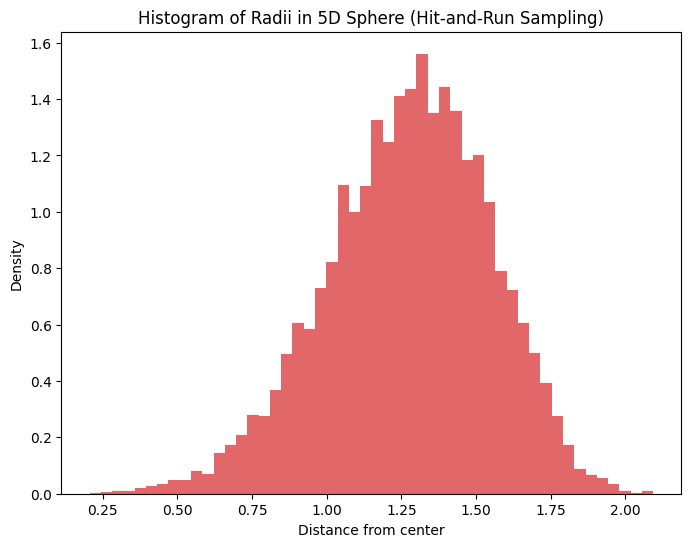

In [ ]:
def hit_and_run_hypercube(d, n_samples, initial=None, step_size=0.5):
    import numpy as np
    if initial is None:
        initial = np.zeros(d)
    samples = np.zeros((n_samples, d))
    current = initial
    for i in range(n_samples):
        direction = np.random.randn(d)
        direction /= np.linalg.norm(direction)
        t_upper = []
        t_lower = []
        for j in range(d):
            if direction[j] > 0:
                t_upper.append((1 - current[j]) / direction[j])
                t_lower.append((-1 - current[j]) / direction[j])
            elif direction[j] < 0:
                t_upper.append((-1 - current[j]) / direction[j])
                t_lower.append((1 - current[j]) / direction[j])
            else:
                t_upper.append(1e9)
                t_lower.append(-1e9)
        t_max = min(t_upper)
        t_min = max(t_lower)
        t = np.random.uniform(t_min, t_max)
        current = current + t * direction
        samples[i, :] = current
    return samples

def estimate_volume_sphere(d, n_samples=100000):
    import numpy as np
    samples = hit_and_run_hypercube(d, n_samples)
    inside = np.sum(np.sum(samples**2, axis=1) <= 1)
    fraction = inside / n_samples
    volume_hypercube = 2 ** d
    return fraction * volume_hypercube

def true_volume_sphere(d, radius=1.0):
    from math import gamma, pi
    return (pi ** (d/2) / gamma(1 + d/2)) * (radius ** d)

d = 5
vol_est = estimate_volume_sphere(d, n_samples=100000)
vol_true = true_volume_sphere(d, radius=1.0)
print(f"Estimated Volume of a {d}D Sphere: {vol_est:.4f}")
print(f"True Volume of a {d}D Sphere: {vol_true:.4f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
radii = np.linalg.norm(hit_and_run_hypercube(d, n_samples=10000), axis=1)
plt.hist(radii, bins=50, density=True, alpha=0.7, color='C3')
plt.xlabel('Distance from center')
plt.ylabel('Density')
plt.title('Histogram of Radii in 5D Sphere (Hit-and-Run Sampling)')
plt.show()

Estimated Integral (d=5): 0.0975
Exact Integral (d=5): 0.1009


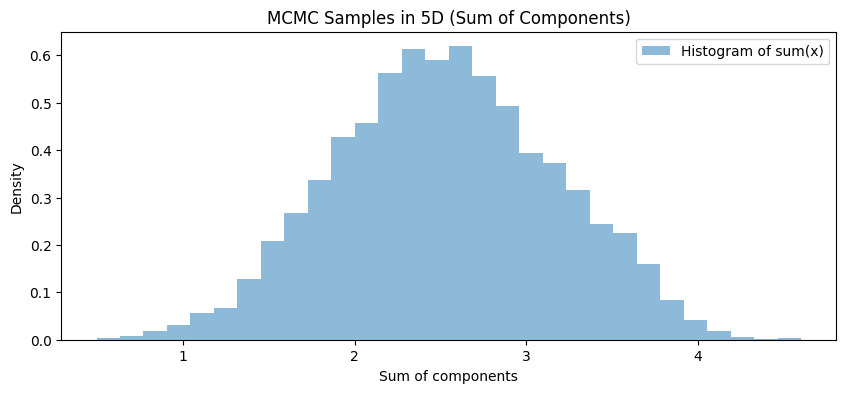

In [ ]:
def uniform_rw_metropolis(d, n_samples=10000, step_size=0.2):
    import numpy as np
    samples = np.zeros((n_samples, d))
    current = np.full(d, 0.5)  # start at the center
    for i in range(n_samples):
        proposal = current + np.random.uniform(-step_size, step_size, size=d)
        if np.all((proposal >= 0) & (proposal <= 1)):
            current = proposal
        samples[i, :] = current
    return samples

def integrand(x):
    import numpy as np
    return np.exp(-np.sum(x))

def mcmc_integration(d, n_samples=10000, step_size=0.2):
    samples = uniform_rw_metropolis(d, n_samples, step_size)
    f_vals = np.array([integrand(x) for x in samples])
    integral_estimate = np.mean(f_vals)
    return integral_estimate, samples

d = 5
integral_estimate, samples = mcmc_integration(d, n_samples=20000, step_size=0.1)
exact = (1 - np.exp(-1)) ** d
print(f"Estimated Integral (d={d}): {integral_estimate:.4f}")
print(f"Exact Integral (d={d}): {exact:.4f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.hist(np.sum(samples, axis=1), bins=30, density=True, alpha=0.5, label='Histogram of sum(x)')
plt.xlabel('Sum of components')
plt.ylabel('Density')
plt.title('MCMC Samples in 5D (Sum of Components)')
plt.legend()
plt.show()

### 3.10 Computing Partition Functions

Consider a 1D Ising model with $N$ spins where the energy for a configuration $s \in \{-1,1\}^N$ is defined as

$$ E(s) = -J \sum_{i=1}^{N-1} s_i s_{i+1}. $$

The unnormalized weight is $w(s) = e^{-\beta E(s)}$. An estimator for the partition function is

$$ Z \approx \frac{2^N}{\frac{1}{n} \sum_{i=1}^n \frac{1}{w(s_i)}}. $$

In [11]:
def ising_energy(state, J=1):
    return -J * np.sum(state[:-1] * state[1:])

def metropolis_ising(state, beta=1.0, n_steps=10000):
    import numpy as np
    current = state.copy()
    states = []
    for _ in range(n_steps):
        i = np.random.randint(0, len(current))
        proposal = current.copy()
        proposal[i] *= -1
        E_current = ising_energy(current)
        E_proposal = ising_energy(proposal)
        if np.random.rand() < np.exp(-beta * (E_proposal - E_current)):
            current = proposal
        states.append(current.copy())
    return np.array(states)

def estimate_partition_function(states, beta=1.0):
    import numpy as np
    weights = np.array([np.exp(-beta * ising_energy(s)) for s in states])
    avg_inv_w = np.mean(1 / weights)
    N_states = 2 ** states.shape[1]
    Z_est = N_states / avg_inv_w
    return Z_est

def exact_partition_function(N, beta=1.0, J=1):
    from itertools import product
    Z = 0
    for state in product([-1, 1], repeat=N):
        state = np.array(state)
        Z += np.exp(-beta * ising_energy(state, J))
    return Z

N = 10
beta_val = 1.0
initial_state = np.ones(N, dtype=int)
states_ising = metropolis_ising(initial_state, beta=beta_val, n_steps=50000)
Z_est = estimate_partition_function(states_ising, beta=beta_val)
Z_exact = exact_partition_function(N, beta=beta_val)
print(f"Estimated Partition Function for N={N}: {Z_est:.4f}")
print(f"Exact Partition Function for N={N}: {Z_exact:.4f}")

Estimated Partition Function for N=10: 46095.6908
Exact Partition Function for N=10: 50792.2610


### 3.11 Epidemiological Modeling

MCMC techniques are used to infer parameters in epidemiological models. In this toy example, we estimate the basic reproduction number $R_0$ from simulated infection counts using a dummy SIR model with a simple squared error likelihood.

Estimated $R_0$: 1.90


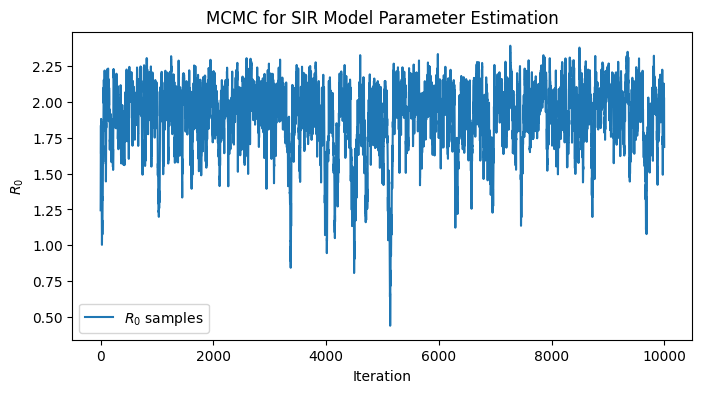

In [13]:
def sir_model(R0, initial_infected=1, population=1000, T=20):
    import numpy as np
    return initial_infected * np.exp(R0 * np.arange(T) / 10)

def epi_likelihood(R0, observed):
    simulated = sir_model(R0, T=len(observed))
    error = np.sum((simulated - observed) ** 2)
    return np.exp(-error / 1000)

def metropolis_epi(observed, n_iter=10000, R0_init=1.5, proposal_std=0.1):
    import numpy as np
    samples = []
    R0_current = R0_init
    like_current = epi_likelihood(R0_current, observed)
    for _ in range(n_iter):
        R0_proposal = np.random.normal(R0_current, proposal_std)
        if R0_proposal <= 0:
            R0_proposal = 0.1
        like_proposal = epi_likelihood(R0_proposal, observed)
        if np.random.rand() < np.exp(np.log(like_proposal + 1e-10) - np.log(like_current + 1e-10)):
            R0_current = R0_proposal
            like_current = like_proposal
        samples.append(R0_current)
    return np.array(samples)

import numpy as np
np.random.seed(0)
observed = sir_model(2.0, T=20) + np.random.normal(0, 5, 20)
epi_samples = metropolis_epi(observed, n_iter=10000, R0_init=1.5, proposal_std=0.1)
print(f"Estimated $R_0$: {np.mean(epi_samples):.2f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(epi_samples, label='$R_0$ samples')
plt.xlabel('Iteration')
plt.ylabel('$R_0$')
plt.title('MCMC for SIR Model Parameter Estimation')
plt.legend()
plt.show()

### 3.12 Cryptographic Decoding

MCMC can be used to search the space of decryption functions for substitution ciphers. In this toy example, a dummy bigram scoring function is used and proposals are generated by swapping two letters in the cipher key.

In [14]:
import string
import random

alphabet = list(string.ascii_uppercase)

# Dummy bigram log-probabilities
bigram_probs = {('T','H'): -0.5, ('H','E'): -0.6, ('E',' '): -0.7, (' ','T'): -0.4}
default_log_prob = -3.0

def score_text(text):
    score = 0.0
    for i in range(len(text) - 1):
        bigram = (text[i], text[i+1])
        score += bigram_probs.get(bigram, default_log_prob)
    return score

def decrypt(ciphertext, mapping):
    return ''.join(mapping.get(c, c) for c in ciphertext)

def propose_mapping(mapping):
    new_mapping = mapping.copy()
    a, b = random.sample(alphabet, 2)
    new_mapping[a], new_mapping[b] = new_mapping[b], new_mapping[a]
    return new_mapping

def mcmc_decoding(ciphertext, n_iterations=5000):
    import numpy as np
    current_mapping = {letter: letter for letter in alphabet}
    current_decoded = decrypt(ciphertext, current_mapping)
    current_score = score_text(current_decoded)
    best_mapping = current_mapping
    best_score = current_score
    for _ in range(n_iterations):
        proposal = propose_mapping(current_mapping)
        proposal_decoded = decrypt(ciphertext, proposal)
        proposal_score = score_text(proposal_decoded)
        if random.random() < np.exp(proposal_score - current_score):
            current_mapping = proposal
            current_score = proposal_score
            if current_score > best_score:
                best_mapping = current_mapping
                best_score = current_score
    return best_mapping, best_score, decrypt(ciphertext, best_mapping)

# Example ciphertext
ciphertext = "GSRH RH Z HVXIVG"
decoded_mapping, score, decoded_text = mcmc_decoding(ciphertext, n_iterations=5000)
print("Decoded Text:", decoded_text)

Decoded Text: NGHE HE T EXQOXN


### 3.13 Simulated Annealing for Global Optimization

Simulated annealing uses an MCMC-like acceptance criterion with a decreasing temperature $T$ to find the global minimum of a multi-modal function. In this example, we minimize

$$ f(x) = x^4 - 16x^2 + 5x. $$

<IPython.core.display.Math object>

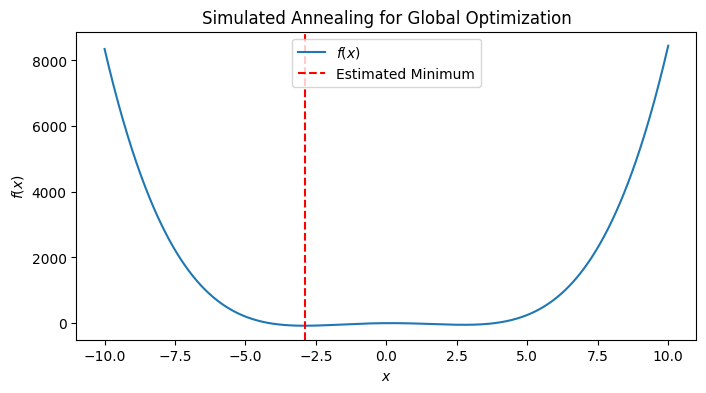

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Math

def f(x):
    return x**4 - 16*x**2 + 5*x

def simulated_annealing(f, x0, n_iter=10000, initial_temp=10.0, cooling_rate=0.0005):
    current = x0
    current_val = f(x0)
    best = current
    best_val = current_val
    temp = initial_temp
    for i in range(n_iter):
        proposal = current + np.random.normal(0, 1.0)
        proposal_val = f(proposal)
        if np.random.rand() < np.exp((current_val - proposal_val) / temp):
            current = proposal
            current_val = proposal_val
            if current_val < best_val:
                best = current
                best_val = current_val
        temp = temp * (1 - cooling_rate)
    return best, best_val

best_x, best_val = simulated_annealing(f, x0=5.0, n_iter=10000, initial_temp=10.0, cooling_rate=0.0005)
display(Math(r" \text{Estimated minimum at } x = %.3f,\quad f(x)=%.3f " 
    % (best_x, best_val)
))
x_vals = np.linspace(-10, 10, 1000)
plt.figure(figsize=(8,4))
plt.plot(x_vals, f(x_vals), label='$f(x)$')
plt.axvline(best_x, color='red', linestyle='--', label='Estimated Minimum')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.title('Simulated Annealing for Global Optimization')
plt.legend()
plt.show()

### 3.14 Molecular Dynamics and Conformational Sampling

MCMC can be used to sample conformational states. For example, consider a toy model for a dihedral angle $\theta$ with potential

$$ U(\theta) = 1 - \cos(2\theta), $$

which has minima at $\theta = 0$ and $\theta = \pi$. A Metropolis sampler is used to sample $\theta$.

Dihedral angle MH Acceptance Rate: 0.911


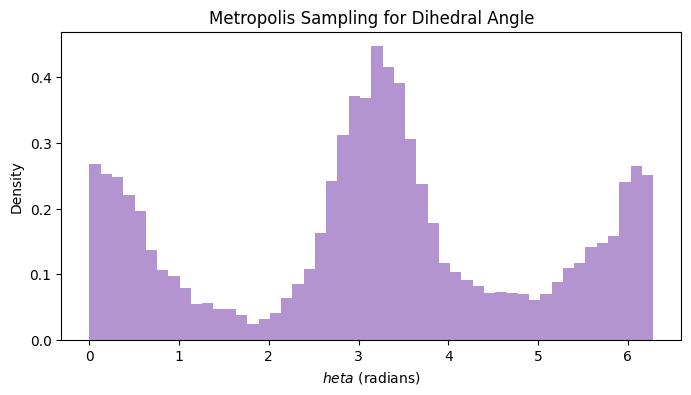

In [16]:
def U_theta(theta):
    import numpy as np
    return 1 - np.cos(2 * theta)

def metropolis_theta(n_samples=10000, theta0=0.0, proposal_std=0.2):
    import numpy as np
    samples = np.zeros(n_samples)
    theta_current = theta0
    U_current = U_theta(theta_current)
    accepted = 0
    for i in range(n_samples):
        theta_proposal = theta_current + np.random.normal(0, proposal_std)
        theta_proposal %= (2 * np.pi)  
        U_proposal = U_theta(theta_proposal)
        if np.random.rand() < np.exp(-(U_proposal - U_current)):
            theta_current = theta_proposal
            U_current = U_proposal
            accepted += 1
        samples[i] = theta_current
    return samples, accepted / n_samples

import numpy as np
theta_samples, acc_rate_theta = metropolis_theta(n_samples=10000, theta0=0.0, proposal_std=0.2)
print(f"Dihedral angle MH Acceptance Rate: {acc_rate_theta:.3f}")
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.hist(theta_samples, bins=50, density=True, alpha=0.7, color='C4')
plt.xlabel('$\theta$ (radians)')
plt.ylabel('Density')
plt.title('Metropolis Sampling for Dihedral Angle')
plt.show()

### 3.15 Geostatistical Modeling

MCMC is applied in spatial statistics to estimate hyperparameters. In this toy example, we simulate 1D spatial data and use MCMC to estimate the length-scale parameter $l$ of an exponential covariance function,

$$ k(x,x') = \exp\Bigl(-\frac{|x-x'|}{l}\Bigr). $$

Estimated length-scale: 1.72


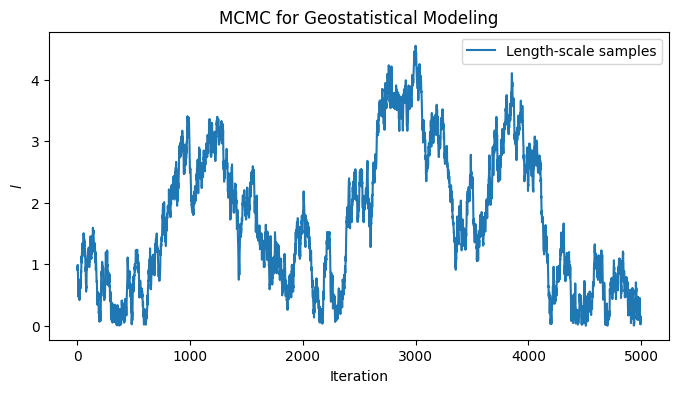

In [17]:
def exp_covariance(x, l):
    import numpy as np
    diff = np.subtract.outer(x, x)
    return np.exp(-np.abs(diff) / l)

def geostat_likelihood(l, x, y):
    import numpy as np
    K = exp_covariance(x, l) + 0.1 * np.eye(len(x))
    L = np.linalg.cholesky(K)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))
    log_det = 2 * np.sum(np.log(np.diag(L)))
    return np.exp(-0.5 * (y.T @ alpha + log_det + len(x) * np.log(2 * np.pi)))

def metropolis_geostat(x, y, n_iter=5000, l_init=1.0, proposal_std=0.1):
    import numpy as np
    samples = []
    l_current = l_init
    like_current = geostat_likelihood(l_current, x, y)
    for i in range(n_iter):
        l_proposal = np.random.normal(l_current, proposal_std)
        if l_proposal <= 0:
            l_proposal = 0.1
        like_proposal = geostat_likelihood(l_proposal, x, y)
        if np.random.rand() < np.exp(np.log(like_proposal + 1e-10) - np.log(like_current + 1e-10)):
            l_current = l_proposal
            like_current = like_proposal
        samples.append(l_current)
    return np.array(samples)

import numpy as np
np.random.seed(0)
x_space = np.linspace(0, 10, 50)
true_l = 2.0
K_true = exp_covariance(x_space, true_l) + 0.1 * np.eye(len(x_space))
y_spatial = np.random.multivariate_normal(np.zeros(len(x_space)), K_true)
geostat_samples = metropolis_geostat(x_space, y_spatial, n_iter=5000, l_init=1.0, proposal_std=0.1)
print(f"Estimated length-scale: {np.mean(geostat_samples):.2f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(geostat_samples, label='Length-scale samples')
plt.xlabel('Iteration')
plt.ylabel('$l$')
plt.title('MCMC for Geostatistical Modeling')
plt.legend()
plt.show()

### 3.16 Population Genetics

MCMC is used to estimate population parameters such as migration or mutation rates. In this toy example, we estimate an allele frequency $p$ using a dummy likelihood function based on binary data.

Estimated allele frequency: 0.497


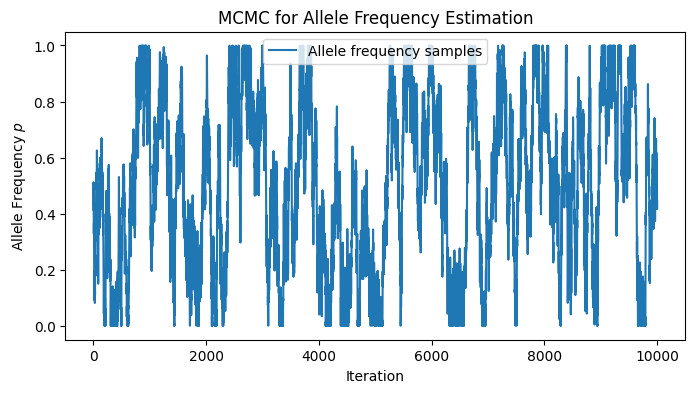

In [20]:
def popgen_likelihood(p, data):
    import numpy as np
    return p ** np.sum(data) * (1 - p) ** (len(data) - np.sum(data))

def metropolis_popgen(data, n_iter=10000, p_init=0.5, proposal_std=0.05):
    import numpy as np
    samples = []
    p_current = p_init
    like_current = popgen_likelihood(p_current, data)
    for _ in range(n_iter):
        p_proposal = np.random.normal(p_current, proposal_std)
        p_proposal = min(max(p_proposal, 0.001), 0.999)
        like_proposal = popgen_likelihood(p_proposal, data)
        if np.random.rand() < np.exp(np.log(like_proposal + 1e-10) - np.log(like_current + 1e-10)):
            p_current = p_proposal
            like_current = like_proposal
        samples.append(p_current)
    return np.array(samples)

import numpy as np
np.random.seed(0)
data = np.random.binomial(1, 0.3, size=50)
popgen_samples = metropolis_popgen(data, n_iter=10000, p_init=0.5, proposal_std=0.05)
print(f"Estimated allele frequency: {np.mean(popgen_samples):.3f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(popgen_samples, label='Allele frequency samples')
plt.xlabel('Iteration')
plt.ylabel('Allele Frequency $p$')
plt.title('MCMC for Allele Frequency Estimation')
plt.legend()
plt.show()

### 3.17 Ecological Modeling

MCMC is used in ecological modeling to analyze species distribution data. In this toy example, we simulate binary presence/absence data using a logistic regression model with a spatial covariate, and we estimate the regression coefficient $\beta$ using a Metropolis sampler.

Estimated β (ecological): 2.32


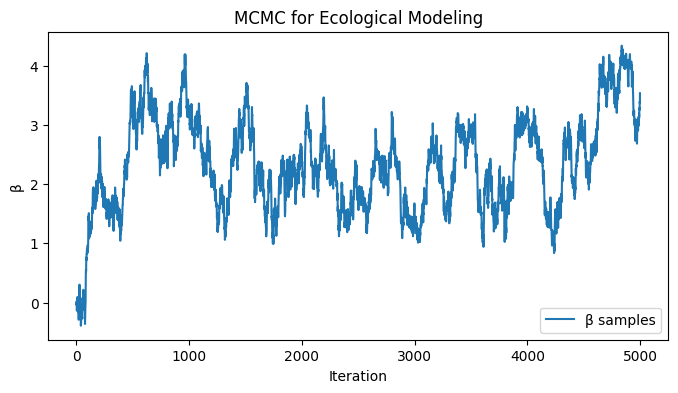

In [21]:
def logistic_likelihood(beta, x, y):
    import numpy as np
    def sigmoid(z):
        return 1 / (1 + np.exp(-z))
    logits = beta * x
    return np.prod(sigmoid(logits) ** y * (1 - sigmoid(logits)) ** (1 - y))

def metropolis_ecological(x, y, n_iter=5000, beta_init=0.0, proposal_std=0.1):
    import numpy as np
    samples = []
    beta_current = beta_init
    like_current = logistic_likelihood(beta_current, x, y)
    for i in range(n_iter):
        beta_proposal = np.random.normal(beta_current, proposal_std)
        like_proposal = logistic_likelihood(beta_proposal, x, y)
        if np.random.rand() < np.exp(np.log(like_proposal + 1e-10) - np.log(like_current + 1e-10)):
            beta_current = beta_proposal
            like_current = like_proposal
        samples.append(beta_current)
    return np.array(samples)

import numpy as np
np.random.seed(42)
n_eco = 100
x_spatial = np.linspace(0, 10, n_eco)
true_beta_eco = 1.5
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
p_true = sigmoid(true_beta_eco * x_spatial)
y_eco = np.random.binomial(1, p_true)
eco_samples = metropolis_ecological(x_spatial, y_eco, n_iter=5000, beta_init=0.0, proposal_std=0.1)
print(f"Estimated β (ecological): {np.mean(eco_samples):.2f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(eco_samples, label='β samples')
plt.xlabel('Iteration')
plt.ylabel('β')
plt.title('MCMC for Ecological Modeling')
plt.legend()
plt.show()

### 3.18 Phylogenetics

MCMC is essential for Bayesian phylogenetic inference, where the goal is to sample over the vast space of evolutionary trees. In this toy example, candidate trees are represented as strings and a dummy scoring function is used. In practice, specialized software (e.g. MrBayes, BEAST) is used.

In [25]:
def dummy_tree_score(tree):
    # Dummy scores for demonstration
    score_map = {"tree1": 5.0, "tree2": 6.0, "tree3": 4.5}
    return score_map.get(tree, 0)

def propose_tree(current_tree, trees):
    import random
    candidates = list(trees)
    candidates.remove(current_tree)
    return random.choice(candidates)

def mcmc_phylo(trees, n_iter=1000):
    import numpy as np
    current_tree = trees[0]
    current_score = dummy_tree_score(current_tree)
    best_tree = current_tree
    best_score = current_score
    samples = []
    for i in range(n_iter):
        proposal = propose_tree(current_tree, trees)
        proposal_score = dummy_tree_score(proposal)
        if np.random.rand() < np.exp(proposal_score - current_score):
            current_tree = proposal
            current_score = proposal_score
            if current_score > best_score:
                best_tree = current_tree
                best_score = current_score
        samples.append(current_tree)
    return samples, best_tree, best_score

trees = ["tree1", "tree2", "tree3"]
phylo_samples, best_tree, best_score = mcmc_phylo(trees, n_iter=1000)
print("Best tree from MCMC phylogenetics simulation:", best_tree)
print("Score:", best_score)

Best tree from MCMC phylogenetics simulation: tree2
Score: 6.0


## 4: Implementation Considerations and Optimizations

### 4.1 Tuning and Step Size Selection

- **MH and Random-Walk Proposals:** Proposals that are too narrow slow down exploration; too wide, and acceptance rates drop. Adaptive tuning during burn-in can mitigate these issues.
- **HMC:** Tune the leapfrog step size ($\epsilon$) and the number of steps carefully. Too large an $\epsilon$ can lead to numerical errors, while too small increases computation time. Adaptive methods (e.g. dual averaging) are often used.

### 4.2 Numerical Stability and Log-Domain Computations

- Use log-domain computations (e.g. the log-sum-exp trick) to prevent underflow when working with very small probabilities.
- When approximating gradients (as in SVI), either choose the finite difference step size carefully or use automatic differentiation.

### 4.3 Initialization and Burn-In

- **Initialization:** Good starting values reduce burn-in time. Running multiple chains with diverse starting points is recommended.
- **Burn-In:** Discard early samples to reduce the influence of initial values.

### 4.4 Diagnostic Checks

- Use trace plots, autocorrelation plots, and effective sample size (ESS) calculations to assess convergence.
- **Gelman-Rubin Statistic ($\hat{R}$):** Compare variances across multiple chains to verify convergence.

### 4.5 Advantages and Limitations

**MCMC Advantages:**
- Asymptotically exact samples (with sufficiently long runs).
- Capable of handling complex, multi-modal distributions.

**MCMC Limitations:**
- Computationally intensive for high-dimensional or complex models.
- Requires careful tuning to achieve good mixing and high ESS.

**VI Advantages:**
- Generally faster and more scalable by framing inference as an optimization problem.
- Compatible with gradient-based optimization methods.

**VI Limitations:**
- Approximations (e.g. mean-field) can underestimate uncertainty.
- May converge to local optima without asymptotic guarantees like MCMC.

### 4.6 Parallelization and Performance Optimizations

- **Parallel Chains:** Use libraries such as `multiprocessing` or `joblib` to run multiple chains concurrently.
- **Vectorization:** Leverage NumPy vectorized operations for computational speed-ups.
- **GPU Acceleration:** Utilize frameworks like TensorFlow, PyTorch, or JAX to run computations on GPUs.
- **Distributed Optimization:** In VI (e.g. SVI, VAEs), distribute computations across nodes or GPUs to handle large datasets.
- **Asynchronous MCMC:** Consider methods that combine samples from chains running in parallel.
- **Optimized Libraries:** Use packages such as Stan, PyMC3, or TensorFlow Probability for high-performance implementations.

## 5: Advanced Variants and Extensions

### 5.1 Advanced MCMC Extensions

**No-U-Turn Sampler (NUTS):** Automatically adjusts the number of leapfrog steps to avoid U-turns. Implementations exist in libraries like PyMC3 or Stan.

**Reversible Jump MCMC (RJMCMC):** Enables transitions between models of different dimensionality (see Green, 1995 for details).

**Parallel Tempering:** Runs multiple chains at different temperatures to help escape local modes.

**Sequential Monte Carlo (SMC):** Propagates weighted particles over time, suitable for dynamic models.

### 5.2 Advanced VI Techniques

**Importance-Weighted Autoencoders (IWAE):** Use multiple samples from $q(z)$ to obtain a tighter lower bound.

**Normalizing Flows:** Transform a simple distribution into a more complex one via invertible mappings.

**Amortized Inference and VAEs:** Neural networks are used to parameterize $q(z|x)$ for efficient large-scale inference.

**Stein Variational Gradient Descent (SVGD):** Updates a set of particles using kernelized gradients from Stein's identity.

## 6: Conclusion and Further Reading

This notebook provided an overview of MCMC and Variational Inference. In summary:

**Markov Chain Monte Carlo (MCMC)** is a class of algorithms for drawing samples from complex probability distributions by constructing a Markov chain whose stationary distribution matches the target distribution. It enables numerical approximation of high-dimensional integrals—such as expectations or marginal likelihoods—that are intractable to compute analytically. In Bayesian statistics, MCMC is the workhorse for estimating posterior distributions, credible intervals, and model parameters in hierarchical or non-conjugate models where closed-form solutions don’t exist. Beyond statistics, MCMC methods power simulations in computational physics (e.g., statistical mechanics), computational biology (e.g., phylogenetic inference), and environmental science (e.g., spatial or ecosystem modeling) due to their flexibility in handling complex likelihood landscapes.

**Variational Inference (VI)** casts the problem of posterior approximation as an optimization task: choose a tractable family of distributions and find the member that minimizes divergence (commonly Kullback–Leibler) to the true posterior. Because it replaces stochastic sampling with deterministic optimization, VI can scale to very large datasets and deliver real-time inference, albeit at the cost of an approximation bias. VI is widely used in models ranging from Bayesian mixtures and topic models (e.g., latent Dirichlet allocation) to modern deep generative architectures such as variational autoencoders, where fast, approximate posteriors are essential for training on massive data.

In short:<br>
	•	Use MCMC when you need high-fidelity posterior estimates or when your model has complex dependencies that are difficult to capture with simple variational families.<br>
	•	Use VI when you require speed and scalability — especially for big data or streaming applications — and can tolerate some approximation error in exchange for tractable inference.<br>

For further details, please consult the references below.

### Further Reading

- Robert, C. P. and Casella, G. (1999). *Monte Carlo Statistical Methods*. Springer.
- Geyer, C. J. (1992). *Practical Markov Chain Monte Carlo*. Statistical Science.
- Diaconis, P. (2008). *The Markov Chain Monte Carlo Revolution*. Bulletin of the AMS.
- Neal, R. M. (2011). *MCMC Using Hamiltonian Dynamics*. In Handbook of MCMC.
- Blei, D. M., Kucukelbir, A., and McAuliffe, J. D. (2018). *Variational Inference: A Review for Statisticians*. JASA.